# Data extraction and cleaning 

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

Get the file path for the data set copied to clipboard 

In [5]:
file_path = r"C:\Users\harry\OneDrive - Loughborough University\25PHC902 Group Project\DriveSim\Data Sets\KIT\10.35097-1130\10.35097-1130\data\dataset\OBD-II-Dataset\OBD-II-Dataset\2017-07-05_Seat_Leon_RT_S_Stau.csv"

Function to turn time into a float 

In [41]:
def timeToFloat(time_column_title):
    # Ensure strings
    s = time_column_title.astype(str).str.strip()
    s = "00:" + s # Convert mm:ss.f → hh:mm:ss.f

    td = pd.to_timedelta(s, errors="coerce")
    if pd.isna(td).any():
        bad = time_column_title[pd.isna(td)].head(10).tolist()
        raise ValueError(f"Unparseable time values (showing up to 10): {bad}")

    seconds = td.dt.total_seconds().to_numpy()

    # ---- UNWRAP ROLLOVER (59:59.9 → 00:00.0) ----
    unwrapped = seconds.copy()
    rollover_offset = 0.0

    for i in range(1, len(seconds)):
        if seconds[i] < seconds[i - 1]:
            # minute counter rolled over
            rollover_offset += 60.0 * 60.0  # add 1 hour
        unwrapped[i] += rollover_offset

    # Normalize to start at 0
    return unwrapped - unwrapped[0]


Function to plot a graph x against y

In [44]:
def PlotXagainstY(x,y,x_column_title, y_column_title):
    plt.figure(figsize=(10, 6))
    plt.plot(x, y, marker='o', linestyle='-', color='blue')
    plt.xlabel(x_column_title)
    plt.ylabel(y_column_title)
    plt.title(f"Line Graph of {y_column_title} against {x_column_title}")
    plt.grid(True)
    plt.show()
    

## Plotting Speed against time 

In [47]:
def convertDataToFormat(file_path, x_column_title): 
    usecols = [x_column_title]
    df = pd.read_csv(file_path, usecols=usecols)
    
    if x_column_title == "Time":
        df[x_column_title] = timeToFloat(df[x_column_title])
    else:
        df[x_column_title] = df[x_column_title]
    df = df.drop(range(0,9))
    
    x = df[x_column_title].to_numpy()
   
    return x

In [49]:
Time = convertDataToFormat(file_path, "Time")

In [51]:
Speed = convertDataToFormat(file_path, "Vehicle Speed Sensor [km/h]")

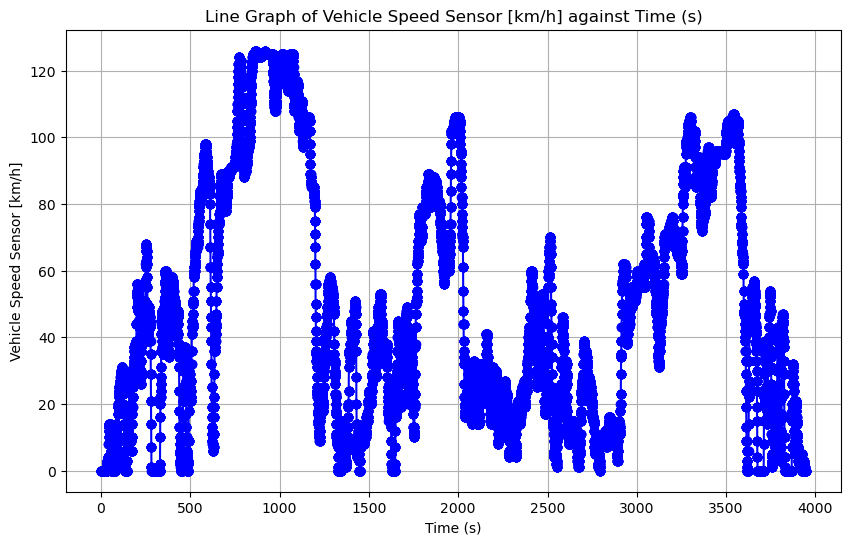

In [53]:
PlotXagainstY(Time,Speed,"Time (s)", "Vehicle Speed Sensor [km/h]")

## Plotting acceleration against time

In [56]:
def computeAcceleration(file_path, time_title, speed_title):
    x = convertDataToFormat(file_path, time_title)
    y = convertDataToFormat(file_path, speed_title)

    acceleration = np.gradient(y,x)
    return acceleration

In [58]:
Acceleration = computeAcceleration(file_path, "Time", "Vehicle Speed Sensor [km/h]")

C:\Users\harry\anaconda3\Lib\site-packages\numpy\lib\function_base.py:1242: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
C:\Users\harry\anaconda3\Lib\site-packages\numpy\lib\function_base.py:1243: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
C:\Users\harry\anaconda3\Lib\site-packages\numpy\lib\function_base.py:1244: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
C:\Users\harry\anaconda3\Lib\site-packages\numpy\lib\function_base.py:1250: RuntimeWarning: invalid value encountered in multiply
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]
C:\Users\harry\anaconda3\Lib\site-packages\numpy\lib\function_base.py:1250: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]
C:\Users\harry\anaconda3\Lib\site-packages\numpy\lib\function_base.py:1259: Runti

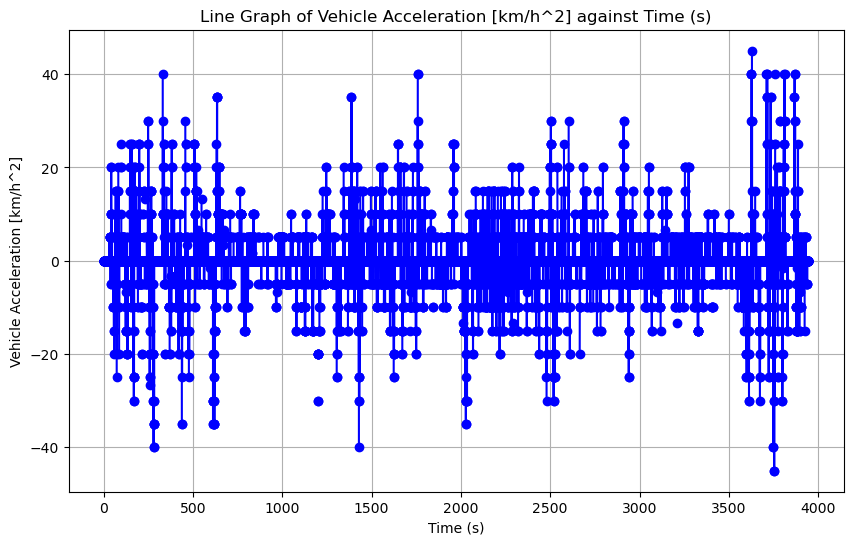

In [60]:
PlotXagainstY(Time,Acceleration,"Time (s)", "Vehicle Acceleration [km/h^2]")

## Distance travelled against time 

In [63]:
def trapiziodalRule(file_path, x_column_title, y_column_title):
    x = convertDataToFormat(file_path, x_column_title)
    y = convertDataToFormat(file_path, y_column_title)
    #print(len(x),len(y))
    
    valid_mask = ~(np.isnan(x) | np.isnan(y))
    x = x[valid_mask]
    y = y[valid_mask]
    print(len(x),len(y))
    
    dx = np.diff(x)
    print(len(dx),len(y))

    integral_at_points = (0.5 * (y[1:] + y[:-1]) * dx)
    #print(len(integral_at_points))

    cumulative_integral = np.cumsum(integral_at_points)
    #print(len(cumulative_integral))

    cumulative_x = np.cumsum(dx)
    
    cumulative_integral_full = np.insert(cumulative_integral, 0, 0)
    cumulative_x_full = np.insert(dx, 0,0)
    #print(len(cumulative_integral_full))
    
    return cumulative_integral_full

In [65]:
def convertTimeIntoHours(file_path, x_column_title):
    usecols = [x_column_title]
    df = pd.read_csv(file_path, usecols=usecols)

    if x_column_title == "Time":
        df[x_column_title] = timeToFloat(df[x_column_title])
    else:
        df[x_column_title] = df[x_column_title]


    
    x = (df[x_column_title].to_numpy())/(3600)

    return x

In [67]:
time = convertTimeIntoHours(file_path,"Time")

In [69]:
time, distance = trapiziodalRule(file_path, "Time", "Vehicle Speed Sensor [km/h]")

46340 46340
46339 46340


ValueError: too many values to unpack (expected 2)

In [71]:
PlotXagainstY(time, distance, "Time (Hrs, "Distance (km)")

SyntaxError: unterminated string literal (detected at line 1) (581571321.py, line 1)

## Fuel Efficiency 

If the data is given in g/s it needs to be converted into kg/s

In [75]:
def massAirFlowInKgS(file_path,massAirFlowTitle): #MAF = mass air flow
    massAirFlow_gps = convertDataToFormat(file_path, massAirFlowTitle)
    #print(massAirFlow_gps)
    massAirFlow_kgps = massAirFlow_gps / 1000
    return massAirFlow_kgps

In [77]:
def fuelMassFlow(massAirFlow_kgpsArray, afr_lambda): #FMF = mass fuel flow
    afr = 14.7 * afr_lambda
    fuelMassFlow_Array = massAirFlow_kgpsArray / afr
    return fuelMassFlow_Array

In [79]:
def carFuelTankFlow(fuelMassFlow_Array, volumeOfFuelTank, typeOfFuel, timeArray):

    fuel_type = typeOfFuel.strip().lower()
    
    if fuel_type == "petrol":
        density = 0.745 
    
    elif fuel_type == "diesel":
        density = 0.832
    else:
        raise ValueError( "Fuel type is not supported. Allowed values are: 'petrol' and 'diesel'."
                         f"Recieved: {typeOfFuel}")

    fuelVolumeFlow_array = fuelMassFlow_Array / density
    
    dt = np.gradient(timeArray)
    fuelUsed = np.cumsum(fuelVolumeFlow_array * dt)
    fuelRemaining = volumeOfFuelTank - fuelUsed
    return fuelVolumeFlow_array, fuelRemaining

In [81]:
MAF_kgps = massAirFlowInKgS(file_path,"Air Flow Rate from Mass Flow Sensor [g/s]")
#print(MAF_kgps)
FMF_kgps = fuelMassFlow(MAF_kgps, 1.0)
#print(FMF_kgps)
fuel_Lps, fuelRemaining = carFuelTankFlow(FMF_kgps, 50.0,"petrol", Time)
#print(fuel_Lps)

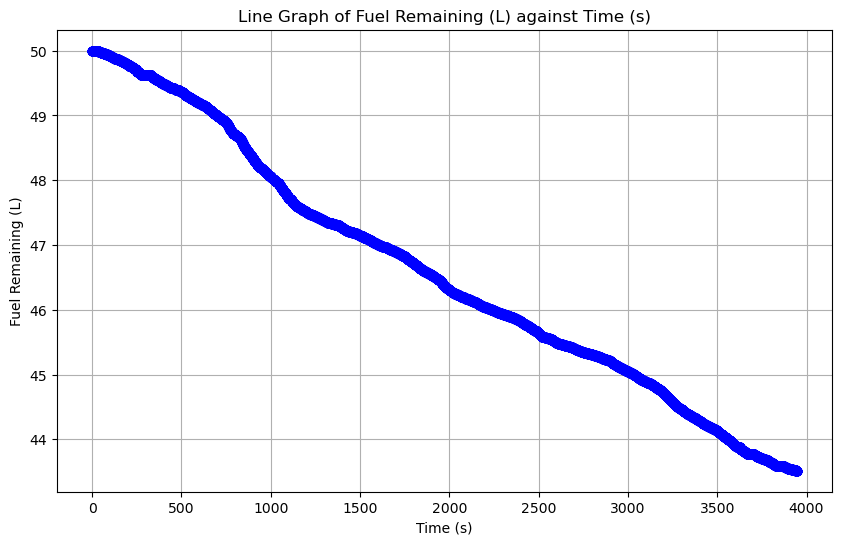

In [83]:
PlotXagainstY(Time,fuelRemaining,"Time (s)", "Fuel Remaining (L)")

### The next method is from the journal article (Tamer A, et. Al).

The method starts with finding the conventional L/100km using;

$ f = \frac{vs \times \alpha}{MAF} \times \beta $ (Equation 1)

Where:

$vs$ = vehicle speed in km/h  (Taken from OBD-II data)

$MAF$ = mass air flow in g/s (Taken from OBD-II data)

$\alpha$ = 7.718 which converts result into US MPG

$\beta$ = 235.215 which converts MPG $ \rightarrow $ L/100km

In [86]:
def fuelConsumptionLPer100KmConventional(file_path, speed_title, MAF_title, stop_speed):
    speedArray = convertDataToFormat(file_path, speed_title).astype(float)
    MAFArray = convertDataToFormat(file_path, MAF_title).astype(float)
    alpha = 7.718
    beta = 235.215
    eps = 1e-6
    
    safe_MAF = np.maximum(MAFArray,eps)
    MPG_us = alpha * (speedArray / safe_MAF)

    valid = (speedArray >= stop_speed) & np.isfinite(MPG_us) & (MPG_us > 0)
    
    fuelConsumption_Lp100km = np.full_like(MPG_us, np.nan, dtype=float)
    fuelConsumption_Lp100km[valid] = beta / MPG_us[valid]

    return fuelConsumption_Lp100km, speedArray, MAFArray

In [88]:
fuelConsumption, speedArray, MAFArray = fuelConsumptionLPer100KmConventional(file_path, "Vehicle Speed Sensor [km/h]", "Air Flow Rate from Mass Flow Sensor [g/s]",1.0)

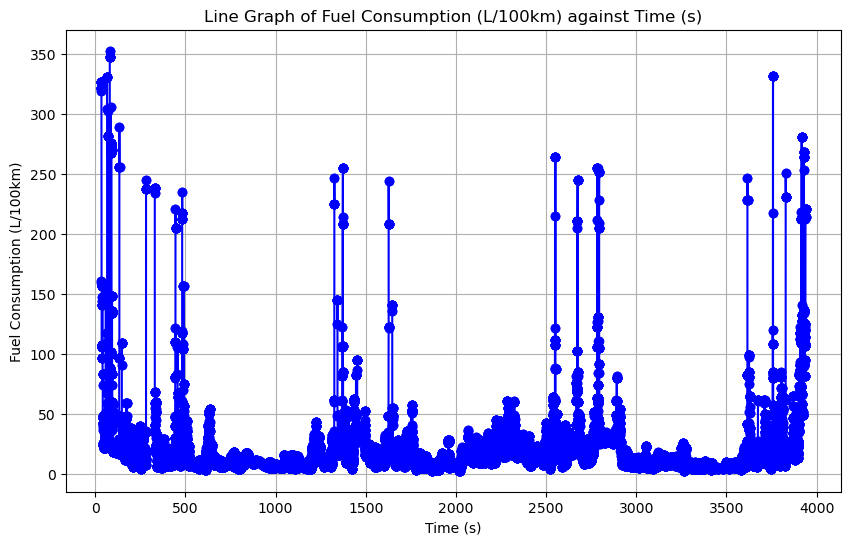

In [90]:
PlotXagainstY(Time,fuelConsumption,"Time (s)", "Fuel Consumption (L/100km)")

This graph blows up when values of speed are low. I use a stop speed value, when speed < stop_speed the code reads it as stop speed. Increasing the stop_speed to get a more relaistic graph is clipping data too much and therefore gives an unrealistic graph. However, setting the stop_speed too low gives massive spikes and the rest of the graph is illegible. I use stop_speed = 1.0 after many trial and errors to find the optimal value thatdoesnt clip too much data but also gives a realistic graph.

(Tamer A, et. Al) argues that using the conventional method of speed and MAF can be unreliable so they use a new equation that includes Engine RPM and Throttle position. 

The method used is to fit curves to the equations:

$FC(RPM) = \alpha RPM^2 + b RPM + c$ (Equation 2)

$FC(TPS) = m TPS + k$ (Equation 3)

Which combine to give a combined surface model:

$FC(RPM,TPS) = A RPM^2 + B RPM + C TPS + D$ (Equation 4)

Then use these fitted curves to predict the FC value for all timestamps

$\hat{FC}(i) = A\times RPM (i)^2 + B\times RPM(i) + C\times TPS(i) + D$ (Equation 5)

The RMSE value can be calculated to compare the conventional FC against the predicted one.

$RMSE = \sqrt{\frac{1}{N}\sum^{N}_{i=1}(\hat{FC}(i) - FC_{conv}(i))^2}$ (Equation 6)

In [94]:
from sklearn.pipeline import Pipeline #chain multiple data processing and model training steps together
from sklearn.preprocessing import StandardScaler #Makes mean 0 and standard deviation 1 (useful for ML)
from sklearn.svm import SVR #Used for effective complex / non-linear regression
from sklearn.metrics import mean_squared_error #Shows average difference between predicted and real value

In [114]:
def curveFittingImprovementFuelConsumption(file_path, fuelConsumption, RPM_title, TPS_title, speed, MAF, speed_mask, clip_negative = True):
    def safe_rmse(a, b, mask):
        a = np.asarray(a, dtype=float)
        b = np.asarray(b, dtype=float)
        m = np.asarray(mask, dtype=bool) & np.isfinite(a) & np.isfinite(b)
        if not np.any(m):
            return np.nan
        return float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))
    
    RPM = convertDataToFormat(file_path, RPM_title).astype(float)
    TPS = convertDataToFormat(file_path, TPS_title).astype(float)

    n = min(len(RPM), len(TPS), len(fuelConsumption), len(speed), len(MAF))
    RPM = RPM[:n]
    TPS = TPS[:n]
    fuelConsumption = np.asarray(fuelConsumption, dtype=float)[:n]
    speed = np.asarray(speed, dtype=float)[:n]
    MAF = np.asarray(MAF, dtype=float)[:n]
    
    valid = (
        np.isfinite(fuelConsumption) &
        np.isfinite(RPM) &
        np.isfinite(TPS) &
        (speed > speed_mask) &
        (MAF > 1e-3)
    )

    RPM_fit = RPM[valid]
    TPS_fit = TPS[valid]
    fuelConsumption_fit = fuelConsumption[valid]

    #Fitting the quadratic to RPM like in the paper

    a, b, c = np.polyfit(RPM_fit, fuelConsumption_fit, 2) #equation 2

    #Fitting a linear curve to TPS like in the paper

    m, k = np.polyfit(TPS_fit, fuelConsumption_fit, 1) #equation 3

    # Now doing the surface fit, combining the two of them

    Phi = np.column_stack([RPM_fit**2, RPM_fit, TPS_fit, np.ones_like(RPM_fit)]) #creating a matrix 
    A, B, C, D = np.linalg.lstsq(Phi, fuelConsumption_fit, rcond=None)[0] #solving with least squares method (equation 4)

    print("FC(RPM) = a*RPM^2 +b*RPM + c,", a, b, c)
    print("FC(TPS) = m*TPS +k,", m, k)
    print("FC(RPM, TCS) = A*RPM^2 +B*RPM + C*TPS + D,", A, B, C, D)

    #now we start predicting FC 
    fuelSurface_prediction = A*(RPM**2) + B*RPM + C*TPS + D #equation 5

    fuelSurface_prediction = np.where(valid,fuelSurface_prediction, np.nan)
    if clip_negative: 
        fuelSurface_prediction = np.where(fuelSurface_prediction >= 0, fuelSurface_prediction, np.nan)

    surface_RMSE = float(np.sqrt(np.mean((fuelSurface_prediction[valid] - fuelConsumption_fit)**2))) #equation 6

    #Now training an SVM regression model

    svr_C = 50.0
    svr_epsilon = 0.05
    svr_gamma = "scale"

    X_fit = np.column_stack([RPM_fit, TPS_fit])

    svr_model = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf", C=svr_C, epsilon=svr_epsilon, gamma=svr_gamma)),
    ])
    svr_model.fit(X_fit, fuelConsumption_fit)

    #Predicitng FC for every row using SVR

    X_all = np.column_stack([RPM,TPS])
    fuelPrediction_svr = svr_model.predict(X_all)

    fuelPrediction_svr =np.where(valid, fuelPrediction_svr, np.nan)
    if clip_negative: 
        fuelPrediction_svr = np.where(fuelPrediction_svr >= 0, fuelPrediction_svr, np.nan)

    svr_RMSE = float(np.sqrt(np.mean((fuelPrediction_svr[valid] - fuelConsumption_fit)**2)))

    valid_pct = float(100.0 * np.sum(valid) / n) if n else np.nan

    fc_valid = fuelConsumption[valid]
    median_fc_conv = float(np.nanmedian(fc_valid)) if fc_valid.size else np.nan
    p95_fc_conv = float(np.nanpercentile(fc_valid, 95)) if fc_valid.size else np.nan

    rmse_conv_vs_surface = safe_rmse(fuelConsumption, fuelSurface_prediction, valid)
    rmse_conv_vs_svr = safe_rmse(fuelConsumption, fuelPrediction_svr, valid)
    
    metrics = {
        "surface_RMSE": surface_RMSE,
        "svr_RMSE": svr_RMSE,
        "valid_samples_%": valid_pct,
        "median_fc_conv": median_fc_conv,
        "p95_fc_conv": p95_fc_conv,
        "rmse_conv_vs_surface": rmse_conv_vs_surface,
        "rmse_conv_vs_svr": rmse_conv_vs_svr,

        "n_total": int(n),
        "n_valid": int(np.sum(valid)),
        "speed_mask": float(speed_mask),
        "clip_negative": bool(clip_negative),
        
    }

    return {
        #Predictions (Equation 5 + 6)
        "fuelSurface_prediction": fuelSurface_prediction,
        "fuelPrediction_svr": fuelPrediction_svr,

        #Coefficient Outputs (Equation 2, 3, 4)
        "RPM quadratic coefficients": (a,b,c),
        "TPS linear coefficients": (m,k),
        "surface coefficients": (A,B,C,D),

        #Model + Metrics
        "svr model": svr_model,
        "validMask": valid,
        "Metrics": metrics,

        #Mask check outputs
        "RMSE_conv_vs_SVR": rmse_conv_vs_svr,
        "RMSE_conv_vs_surface": rmse_conv_vs_surface,
        
    }
    

In [108]:
output = curveFittingImprovementFuelConsumption(file_path, fuelConsumption, "Engine RPM [RPM]", "Absolute Throttle Position [%]", speedArray, MAFArray, 5)

FC(RPM) = a*RPM^2 +b*RPM + c, 1.464828373011504e-05 -0.04961954733981886 54.252639120699854
FC(TPS) = m*TPS +k, -0.1250729321964588 25.106452608552306
FC(RPM, TCS) = A*RPM^2 +B*RPM + C*TPS + D, 1.445611145325865e-05 -0.04919159038378429 -0.13592363478108554 65.29900004826648


In [109]:
class FuelConsumptionPlots:
    def __init__(self, time, speed, fuelConsumption, outputCurveFitting, maxScatterPoints):
        self.time = time
        self.speed = speed
        self.fuelConsumption = fuelConsumption
        self.outputCurveFitting = outputCurveFitting
        self.maxScatterPoints = maxScatterPoints

        self.fuelSurface_prediction = self.outputCurveFitting["fuelSurface_prediction"]
        self.fuelPrediction_svr = self.outputCurveFitting["fuelPrediction_svr"]
        self.valid = self.outputCurveFitting["validMask"]
        
    def timeSeriesComparison(self):
    
        plt.figure()
        plt.plot(self.time[self.valid], self.fuelConsumption[self.valid], label = "Conventional (Speed+MAF)")
        plt.plot(self.time[self.valid], self.fuelSurface_prediction[self.valid], label = "Surface Fit (RPM + TPS)")
        plt.plot(self.time[self.valid], self.fuelPrediction_svr[self.valid], label = "SVR (RPM + TPS)")
        plt.xlabel("Time (s)")
        plt.ylabel("Fuel consumption (L/100km)")
        plt.title("Fuel consumption vs Time (valid samples)")
        plt.legend()
        plt.show()
    
    def parityPlots(self):
        self.index = np.where(self.valid)[0]
        if len(self.index) > self.maxScatterPoints:
            range = np.random.default_rng(0)
            self.index = range.choice(self.index, size = self.maxScatterPoints, replace = False)

        plt.figure()
        plt.scatter(self.fuelConsumption[self.index], self.fuelSurface_prediction[self.index], s=8, alpha = 0.3)
        mn = np.nanmin([self.fuelConsumption[self.index], self.fuelSurface_prediction[self.index]])
        mx = np.nanmax([self.fuelConsumption[self.index], self.fuelSurface_prediction[self.index]])
        plt.plot([mn,mx], [mn,mx], linewidth = 1)
        plt.xlabel("Conventional Fuel Consumption (L/100km)")
        plt.ylabel("Surface Prediction (L/100km)")
        plt.title("Parity: Surface fit vs Conventional")
        plt.show()

        plt.figure()
        plt.scatter(self.fuelConsumption[self.index], self.fuelPrediction_svr[self.index], s=8, alpha = 0.3)
        mn = np.nanmin([self.fuelConsumption[self.index], self.fuelPrediction_svr[self.index]])
        mx = np.nanmax([self.fuelConsumption[self.index], self.fuelPrediction_svr[self.index]])
        plt.plot([mn,mx], [mn,mx], linewidth = 1)
        plt.xlabel("Conventional Fuel Consumption (L/100km)")
        plt.ylabel("Surface Prediction (L/100km)")
        plt.title("Parity: SVR Prediction vs Conventional")
        plt.show()

    def residualPlot(self):
        residualSurface = self.fuelSurface_prediction - self.fuelConsumption
        residualSVR = self.fuelPrediction_svr - self.fuelConsumption
        
        self.residualSurface = residualSurface
        self.residualSVR = residualSVR
    
        plt.figure()
        plt.plot(self.time[self.valid], self.residualSurface[self.valid], label = "Residual Surface (Pred - Conv)")
        plt.plot(self.time[self.valid], self.residualSVR[self.valid], label = "Residual SVR (Pred - Conv)")
        plt.axhline(0, linewidth = 1)
        plt.xlabel("Time")
        plt.ylabel("Residual (L/100km)")
        plt.title("Residuals vs Time (Valid Samples)")
        plt.show
        

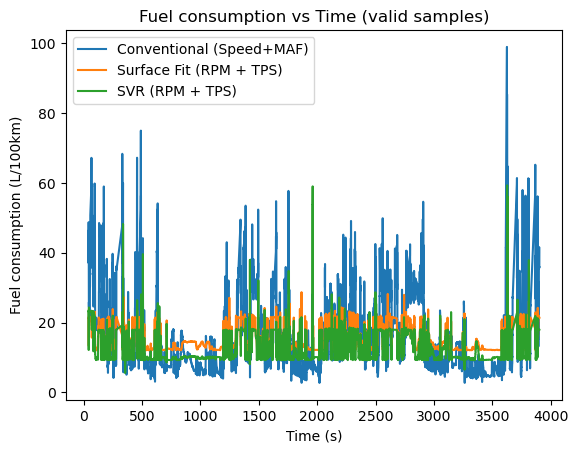

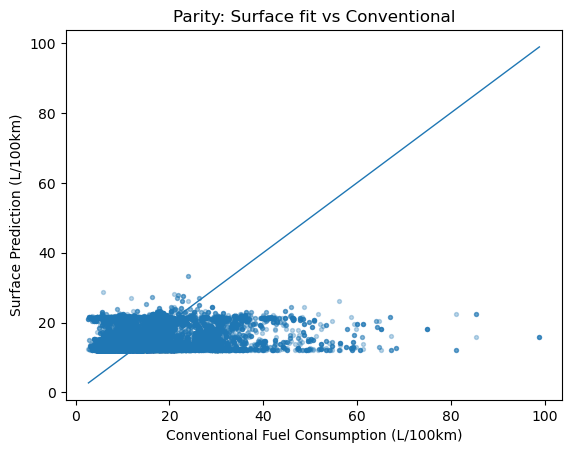

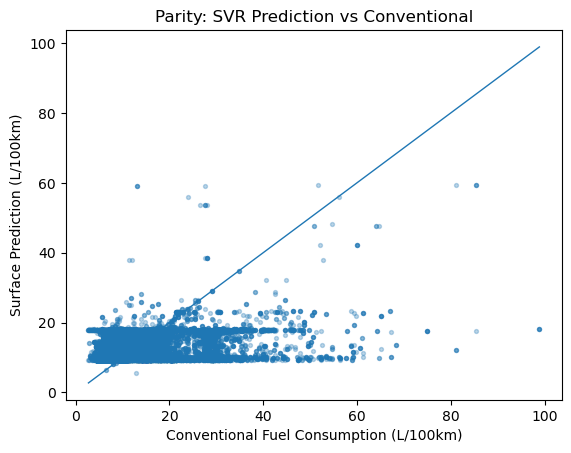

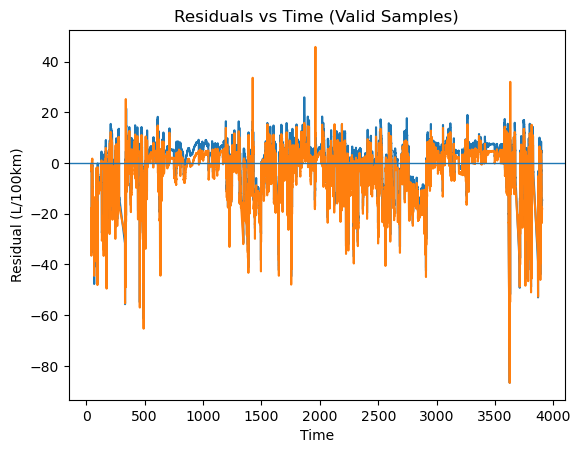

In [110]:
fuelPlots = FuelConsumptionPlots(Time, speedArray, fuelConsumption, output, 20000)
fuelPlots.timeSeriesComparison()
fuelPlots.parityPlots()
fuelPlots.residualPlot()

I will now compare the changing of my speed mask to discuss the use of it

In [119]:
VMINS = [1,3,5]
rows = []
outputs = {}

for vmin in VMINS:
    out = curveFittingImprovementFuelConsumption(file_path, fuelConsumption, "Engine RPM [RPM]", "Absolute Throttle Position [%]", speedArray, MAFArray,speed_mask=vmin,)

    outputs[vmin] = out
    m = out["Metrics"]
    rows.append(m)

df_metrics = pd.DataFrame(rows).sort_values("speed_mask")
df_metrics

FC(RPM) = a*RPM^2 +b*RPM + c, 3.3686152068715106e-05 -0.11372696783545667 106.80755870317385
FC(TPS) = m*TPS +k, -0.08170682722312594 23.833965599489982
FC(RPM, TCS) = A*RPM^2 +B*RPM + C*TPS + D, 3.3541788753126414e-05 -0.1134258259818724 -0.11491433959386968 116.19595054126422
FC(RPM) = a*RPM^2 +b*RPM + c, 1.9075380399172244e-05 -0.06470448818779252 66.7819478694654
FC(TPS) = m*TPS +k, -0.1133321185846029 24.720357732008296
FC(RPM, TCS) = A*RPM^2 +B*RPM + C*TPS + D, 1.8900058975091167e-05 -0.06432395589479409 -0.1299592558336526 77.3673460595075
FC(RPM) = a*RPM^2 +b*RPM + c, 1.464828373011504e-05 -0.04961954733981886 54.252639120699854
FC(TPS) = m*TPS +k, -0.1250729321964588 25.106452608552306
FC(RPM, TCS) = A*RPM^2 +B*RPM + C*TPS + D, 1.445611145325865e-05 -0.04919159038378429 -0.13592363478108554 65.29900004826648


,surface_RMSE,svr_RMSE,valid_samples_%,median_fc_conv,p95_fc_conv,rmse_conv_vs_surface,rmse_conv_vs_svr,n_total,n_valid,speed_mask,clip_negative
0,15.200060,NaN,93.072939,12.250091,42.536011,15.200060,14.993418,46340,43130,1.0,True
1,10.106161,10.292301,91.324989,11.927261,35.551103,10.106161,10.292301,46340,42320,3.0,True
2,9.242692,9.318297,90.073371,11.647034,32.778082,9.242692,9.318297,46340,41740,5.0,True
